# Analysis of Daily Activity Dataset

### Overview
Detailed analysis of daily activity data, including trend visualizations, descriptive statistics, and correlation analysis, along with inferences and future recommendations.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
import numpy as np

# Load the dataset
file_path = 'dailyActivity.csv'
data = pd.read_csv(file_path)

# Convert 'Date' column to datetime format for consistency in time-based analysis
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')


## Data Overview

In [15]:
data.head()

,Date,Calories (kcal),Distance (m),Step count
0,2024-07-16,1831.135792,4962.084056,7926.0
1,2024-07-17,1999.689964,10166.573300,6482.0
2,2024-07-18,1795.581708,3821.736487,7473.0
3,2024-07-22,NaN,NaN,NaN
4,2024-07-23,1707.448657,1054.445278,7409.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             100 non-null    datetime64[ns]
 1   Calories (kcal)  84 non-null     float64       
 2   Distance (m)     84 non-null     float64       
 3   Step count       97 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 3.2 KB


# Data Cleaning
#### Days When I didn't wore watch!
- Identify
- Replace with nan

In [17]:
threshold=1000
steps_below_threshold = data[data['Step count'] < threshold].shape[0]
print(f"Number of steps below {threshold}: {steps_below_threshold}")

Number of steps below 1000: 13


In [18]:
data.loc[data['Step count'] < threshold, 'Step count'] = np.nan

- Identify Missing values

In [19]:
data.isna().sum()

Date                0
Calories (kcal)    16
Distance (m)       16
Step count         16
dtype: int64

- Imputing Missing values

In [20]:
# Calculate the mean for each field by day of the week
mean_values_by_day = data.groupby(data['Date'].dt.day_name()).mean()

# Function to replace missing values with the mean of the corresponding day of the week
def replace_with_mean(row):
    for column in data.columns:
        if pd.isna(row[column]):
            row[column] = mean_values_by_day.loc[row['Date'].day_name(), column]
    return row

# Apply the function to the dataframe
df = data.apply(replace_with_mean, axis=1)


## Descriptive Statistics

In [21]:
df.describe()

,Date,Calories (kcal),Distance (m),Step count
count,100,100.000000,100.000000,100.000000
mean,2024-09-06 09:50:24,1775.823056,3124.337373,6192.171142
min,2024-07-16 00:00:00,1558.651338,58.738222,1016.000000
25%,2024-08-12 18:00:00,1717.024337,1054.409784,2089.166667
50%,2024-09-06 12:00:00,1762.382145,2974.414388,6558.636364
75%,2024-10-01 06:00:00,1814.295718,4356.911317,8663.500000
max,2024-10-26 00:00:00,2043.661751,10166.573300,15598.000000
std,NaN,82.276068,2173.846588,3589.680140


## Plot: Daily Step Count Over Time

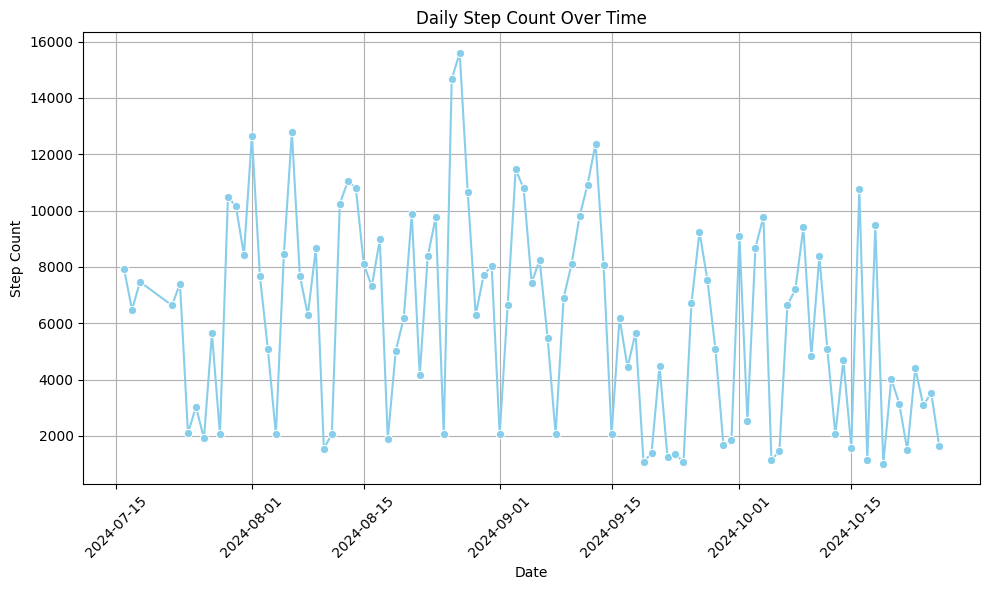

In [22]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Step count', data=df, marker='o', color='skyblue')
plt.xlabel('Date')
plt.ylabel('Step Count')
plt.title('Daily Step Count Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

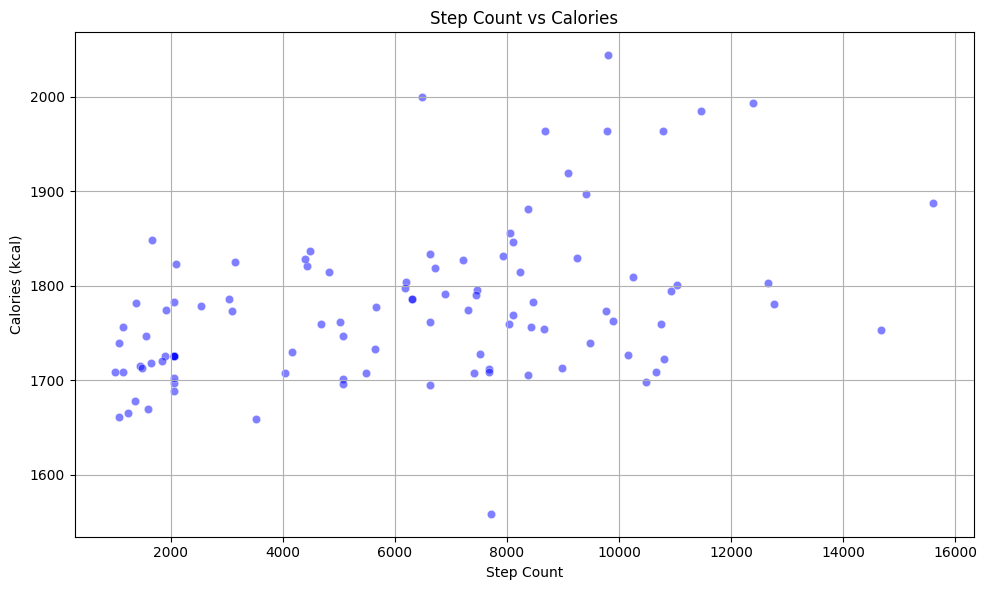

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Step count', y='Calories (kcal)', data=df,color='blue', alpha=0.5)
plt.xlabel('Step Count')
plt.ylabel('Calories (kcal)')
plt.title('Step Count vs Calories')
plt.grid(True)
plt.tight_layout()
plt.show()

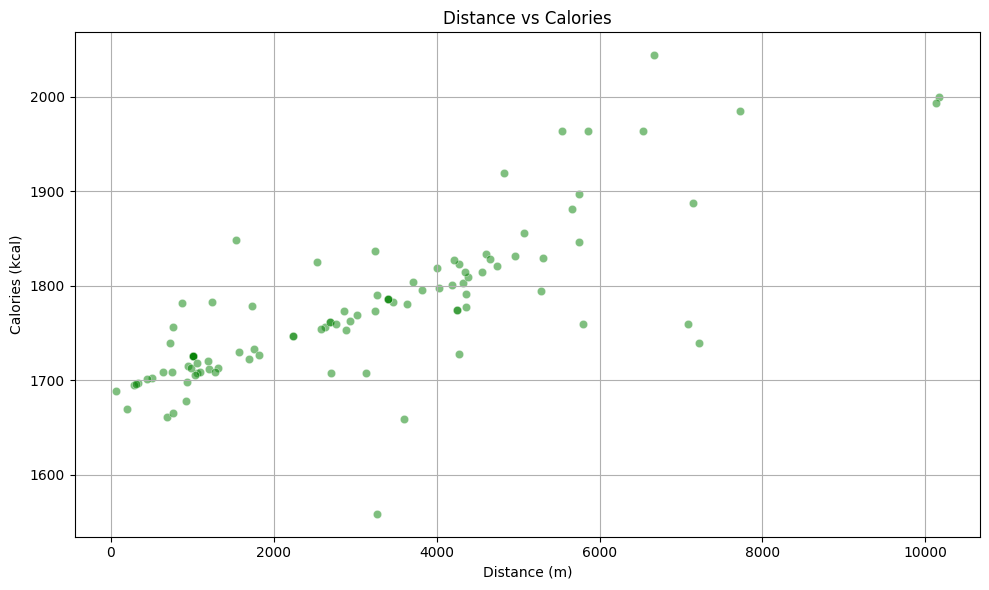

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance (m)', y='Calories (kcal)', data=df,color='green', alpha=0.5)
plt.xlabel('Distance (m)')
plt.ylabel('Calories (kcal)')
plt.title('Distance vs Calories')
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
average_steps_per_day = df.groupby(data['Date'].dt.day_name())['Step count'].mean()
print(average_steps_per_day.sort_values())

Date
Sunday       2062.666667
Saturday     5072.363636
Thursday     6298.230769
Monday       6635.272727
Friday       7309.076923
Tuesday      7705.066667
Wednesday    7741.266667
Name: Step count, dtype: float64


In [26]:
holiday_threshold=3000
# Filter the dataframe for step counts below holiday threshold
days_below_3000 = df[df['Step count'] < holiday_threshold]

# Extract the day of the week for these days
days_below_3000['Day of Week'] = days_below_3000['Date'].dt.day_name()

# Get the frequency of each day of the week
day_frequency = days_below_3000['Day of Week'].value_counts()
print("------------Days Counts below 3000 steps------------")
print(day_frequency)

------------Days Counts below 3000 steps------------
Day of Week
Sunday       12
Saturday      4
Tuesday       3
Wednesday     2
Friday        2
Thursday      2
Monday        2
Name: count, dtype: int64


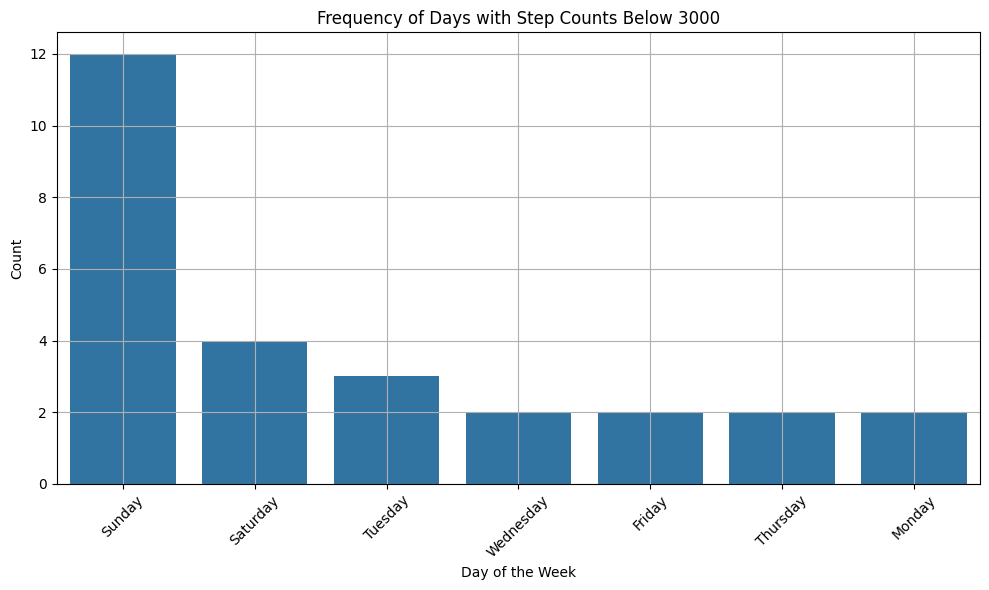

In [27]:
# Convert the Series to a DataFrame and reset the index
day_frequency_df = day_frequency.reset_index()
day_frequency_df.columns = ['Day of the Week', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Day of the Week', y='Count', data=day_frequency_df)
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.title('Frequency of Days with Step Counts Below 3000')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Correlation Analysis

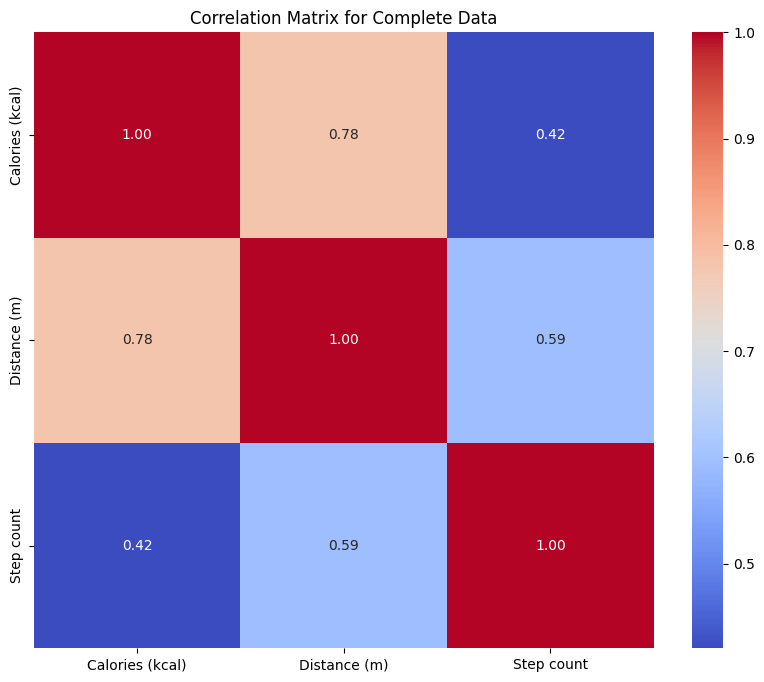

In [28]:
corr_data=df.drop(['Date'], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Complete Data")
plt.show()
    


# Summary of Analysis

### Intuition, Objectives, and Challenges

**Intuition**: The dataset captures daily metrics related to physical activity, useful for tracking health and fitness patterns.

**Objectives**: Monitor activity levels, identify high-activity days, and assess calorie burn.

**Challenges**: Handling missing data, ensuring data consistency, and interpreting correlations carefully.

### Inferences
- Higher step counts and speeds correlate with higher calorie burn.
- Heart rate data shows varying cardiovascular effort, helpful for fitness planning.
- Activity levels fluctuate, with some days showing peak activity.

### Future Scope
1. **Time-Series Analysis** for trends and goal-setting.
2. **Predictive Modeling** for calorie and activity forecasting.
3. **Activity Classification** to label sedentary vs. active days.
4. **Personalized Recommendations** for fitness or dietary guidance.
    